# ACL Smart-Scaffold Digital Twin: Forward Simulation and Parameter Estimation

This notebook is a **synthetic proof of concept** for an ACL smart-scaffold digital twin. It has two connected parts:

1. **Forward problem:** Given mechanical parameters and an applied force, predict scaffold displacement.
2. **Inverse problem:** Given applied force and noisy displacement measurements, estimate the unknown parameters that best explain the data.

The notebook estimates:

\[
k_{\min}, \qquad c_{\min}, \qquad \alpha
\]

The current results verify the numerical method using synthetic data. They are **not yet hardware validation or evidence of biological healing**.

## 1. Mathematical model

The scaffold and test fixture are represented as a time-varying spring-mass-damper system:

\[
m\ddot{x}(t)+c(t)\dot{x}(t)+k(t)x(t)=F(t)
\]

where:

- \(F(t)\) is the known applied force,
- \(x(t)\) is displacement,
- \(m\) is the known effective moving mass,
- \(k(t)\) is time-varying stiffness,
- \(c(t)\) is time-varying damping.

A bounded condition state \(q(t)\) evolves according to:

\[
\frac{dq}{dt}=\alpha(1-q)
\]

and maps to stiffness and damping through:

\[
k(t)=k_{\min}+\left(k_{\max}-k_{\min}\right)q(t)
\]

\[
c(t)=c_{\min}+\left(c_{\max}-c_{\min}\right)q(t)
\]

In this first inverse problem, \(m\), \(k_{\max}\), \(c_{\max}\), and the initial conditions are treated as known. The optimizer estimates \(k_{\min}\), \(c_{\min}\), and \(\alpha\).

## 2. Imports and known experimental settings

The code intentionally uses ordinary variables and small functions rather than dataclasses or custom classes. This keeps the numerical workflow visible to readers with general Python experience.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# Reproducible numerical experiment settings
duration = 12.0                 # seconds
dt = 0.005                      # seconds
mass = 1.0                      # kg
q0 = 0.0                        # initial condition state
x0 = 0.0                        # initial displacement, m
v0 = 0.0                        # initial velocity, m/s
k_max = 40.0                    # N/m, treated as known
c_max = 1.5                     # N*s/m, treated as known
noise_std = 0.002               # m, synthetic displacement sensor noise
random_seed = 123


def create_time_array(duration, dt):
    """Create uniformly spaced samples from 0 to duration, including both endpoints."""
    if duration <= 0:
        raise ValueError("duration must be positive")
    if dt <= 0:
        raise ValueError("dt must be positive")

    number_of_steps = int(round(duration / dt))
    return np.linspace(0.0, duration, number_of_steps + 1)


time = create_time_array(duration, dt)
print(f"Number of time samples: {len(time)}")
print(f"Time step: {time[1] - time[0]:.6f} s")

Number of time samples: 2401
Time step: 0.005000 s


## 3. Applied force used for parameter identification

A constant force mostly reveals static stiffness after motion settles. To distinguish stiffness, damping, and the rate parameter \(\alpha\), the synthetic experiment uses multiple frequencies, a changing baseline, and two brief pulses.

This is called **persistent excitation**: the input creates enough displacement, velocity, and transient behavior for different parameters to leave distinguishable signatures in the measured response.

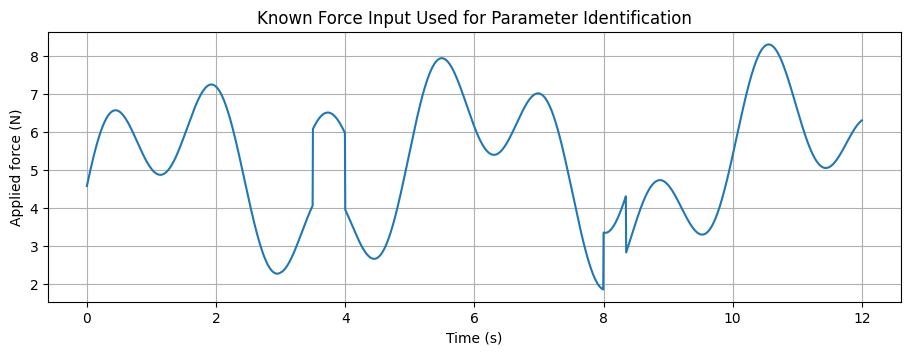

In [ ]:
def create_force_input(time):
    """Create a nonnegative, information-rich force profile for identification."""
    time = np.asarray(time, dtype=float)
    if time.ndim != 1 or len(time) < 2:
        raise ValueError("time must be a one-dimensional array with at least two samples")

    force = (
        4.0
        + 2.0 * np.sin(1.3 * time)
        + 1.5 * np.sin(3.7 * time + 0.4)
        + np.clip(time / 3.0, 0.0, 1.0)
    )

    # Add two short transient loads.
    force += 2.0 * ((time >= 3.5) & (time < 4.0))
    force += 1.5 * ((time >= 8.0) & (time < 8.35))

    # The benchtop rig is assumed to apply tension rather than compression.
    return np.maximum(force, 0.0)


force = create_force_input(time)

plt.figure(figsize=(11, 3.5))
plt.plot(time, force)
plt.xlabel("Time (s)")
plt.ylabel("Applied force (N)")
plt.title("Known Force Input Used for Parameter Identification")
plt.grid(True)
plt.show()

## 4. Condition-state and mechanical-parameter functions

The differential equation for \(q(t)\) is advanced with the forward-Euler update:

\[
q_{j+1}=q_j+\Delta t\,\alpha(1-q_j)
\]

The computed state is clipped to \([0,1]\). The same \(q(t)\) is then mapped to stiffness and damping using the equations above.

In [ ]:
def calculate_condition_state(time, alpha, q0=0.0):
    """Calculate q(t) from dq/dt = alpha*(1-q) with forward Euler."""
    time = np.asarray(time, dtype=float)

    if time.ndim != 1 or len(time) < 2:
        raise ValueError("time must contain at least two samples")
    if alpha < 0:
        raise ValueError("alpha must be nonnegative")
    if not 0.0 <= q0 <= 1.0:
        raise ValueError("q0 must be between 0 and 1")

    condition = np.zeros_like(time)
    condition[0] = q0

    for index in range(len(time) - 1):
        current_dt = time[index + 1] - time[index]
        if current_dt <= 0:
            raise ValueError("time values must be strictly increasing")

        condition[index + 1] = condition[index] + current_dt * alpha * (
            1.0 - condition[index]
        )
        condition[index + 1] = np.clip(condition[index + 1], 0.0, 1.0)

    return condition


def calculate_stiffness_and_damping(
    condition,
    k_min,
    k_max,
    c_min,
    c_max,
):
    """Map the condition state q(t) to time-varying stiffness and damping."""
    condition = np.asarray(condition, dtype=float)

    if k_min < 0 or k_max < k_min:
        raise ValueError("stiffness limits must satisfy 0 <= k_min <= k_max")
    if c_min < 0 or c_max < c_min:
        raise ValueError("damping limits must satisfy 0 <= c_min <= c_max")
    if np.any((condition < 0.0) | (condition > 1.0)):
        raise ValueError("condition values must remain between 0 and 1")

    stiffness = k_min + (k_max - k_min) * condition
    damping = c_min + (c_max - c_min) * condition
    return stiffness, damping

## 5. Central finite-difference forward solver

The motion equation is evaluated numerically. At time index \(j\), central differences approximate velocity and acceleration:

\[
\dot{x}_j\approx\frac{x_{j+1}-x_{j-1}}{2\Delta t}
\]

\[
\ddot{x}_j\approx\frac{x_{j+1}-2x_j+x_{j-1}}{\Delta t^2}
\]

Substituting these expressions into the spring-mass-damper equation and solving for \(x_{j+1}\) gives the recurrence implemented below. The same solver is used for both synthetic-data generation and every optimizer candidate, avoiding duplicated physics.

In [ ]:
def simulate_displacement(
    time,
    force,
    mass,
    stiffness,
    damping,
    x0=0.0,
    v0=0.0,
):
    """Solve m*x'' + c*x' + k*x = F with central finite differences."""
    time = np.asarray(time, dtype=float)
    force = np.asarray(force, dtype=float)
    stiffness = np.asarray(stiffness, dtype=float)
    damping = np.asarray(damping, dtype=float)

    if mass <= 0:
        raise ValueError("mass must be positive")
    if time.ndim != 1 or len(time) < 2:
        raise ValueError("time must contain at least two samples")
    if force.shape != time.shape:
        raise ValueError("force must have the same shape as time")
    if stiffness.shape != time.shape or damping.shape != time.shape:
        raise ValueError("stiffness and damping must have the same shape as time")
    if np.any(stiffness < 0) or np.any(damping < 0):
        raise ValueError("stiffness and damping must be nonnegative")

    time_steps = np.diff(time)
    if np.any(time_steps <= 0):
        raise ValueError("time must be strictly increasing")
    if not np.allclose(time_steps, time_steps[0]):
        raise ValueError("time samples must be uniformly spaced")

    dt = time_steps[0]
    displacement = np.zeros_like(time)
    displacement[0] = x0

    # The recurrence requires x[0] and x[1]. A Taylor expansion supplies x[1].
    initial_acceleration = (
        force[0] - damping[0] * v0 - stiffness[0] * x0
    ) / mass
    displacement[1] = x0 + dt * v0 + 0.5 * dt**2 * initial_acceleration

    for index in range(1, len(time) - 1):
        denominator = mass / dt**2 + damping[index] / (2.0 * dt)

        current_term = (
            2.0 * mass / dt**2 - stiffness[index]
        ) * displacement[index]

        previous_term = (
            damping[index] / (2.0 * dt) - mass / dt**2
        ) * displacement[index - 1]

        displacement[index + 1] = (
            force[index] + current_term + previous_term
        ) / denominator

    return displacement


def run_forward_model(
    time,
    force,
    k_min,
    c_min,
    alpha,
    mass,
    k_max,
    c_max,
    q0=0.0,
    x0=0.0,
    v0=0.0,
):
    """Run the complete q(t) -> k(t), c(t) -> displacement workflow."""
    condition = calculate_condition_state(time, alpha, q0)
    stiffness, damping = calculate_stiffness_and_damping(
        condition,
        k_min,
        k_max,
        c_min,
        c_max,
    )
    displacement = simulate_displacement(
        time,
        force,
        mass,
        stiffness,
        damping,
        x0,
        v0,
    )

    return {
        "condition": condition,
        "stiffness": stiffness,
        "damping": damping,
        "displacement": displacement,
    }

## 6. Generate synthetic smart-scaffold sensor data

Until the benchtop hardware is complete, a known parameter set is used to generate a clean response. Gaussian sensor noise is then added:

\[
x_{\text{sensor}}(t)=x_{\text{true}}(t)+\eta(t),
\qquad
\eta\sim\mathcal{N}(0,\sigma^2)
\]

The true values are shown only so that parameter-recovery accuracy can be evaluated. The optimizer receives the force and noisy displacement, not the hidden true parameter values.

In [ ]:
# Hidden ground-truth parameters used only to create the synthetic experiment.
true_k_min = 11.5                # N/m
true_c_min = 0.22                # N*s/m
true_alpha = 0.24                # 1/s

true_model = run_forward_model(
    time=time,
    force=force,
    k_min=true_k_min,
    c_min=true_c_min,
    alpha=true_alpha,
    mass=mass,
    k_max=k_max,
    c_max=c_max,
    q0=q0,
    x0=x0,
    v0=v0,
)

random_number_generator = np.random.default_rng(random_seed)
sensor_noise = random_number_generator.normal(0.0, noise_std, size=time.shape)
sensor_displacement = true_model["displacement"] + sensor_noise

synthetic_sensor_data = pd.DataFrame({
    "time_s": time,
    "force_N": force,
    "displacement_m": sensor_displacement,
})

synthetic_sensor_data.to_csv(
    "acl_master_synthetic_sensor_data.csv",
    index=False,
)

print("Synthetic sensor file saved as acl_master_synthetic_sensor_data.csv")
synthetic_sensor_data.head()

Synthetic sensor file saved as acl_master_synthetic_sensor_data.csv


,time_s,force_N,displacement_m
0,0.000,4.584128,-0.001978
1,0.005,4.624252,-0.000678
2,0.010,4.664168,0.002806
3,0.015,4.703865,0.000907
4,0.020,4.743334,0.002766


## 7. Formulate the inverse problem

For one candidate parameter vector

\[
\boldsymbol{\theta}=
\begin{bmatrix}
k_{\min} & c_{\min} & \alpha
\end{bmatrix},
\]

the residual at each sample is

\[
r_j(\boldsymbol{\theta})=
\frac{x_{\text{model}}(t_j;\boldsymbol{\theta})-x_{\text{sensor}}(t_j)}{\sigma}.
\]

`scipy.optimize.least_squares` repeatedly calls the residual function, reruns the forward simulation, and changes the three candidate parameters to minimize the sum of squared residuals.

In [ ]:
def parameter_residuals(
    parameter_values,
    time,
    force,
    measured_displacement,
    noise_std,
    mass,
    k_max,
    c_max,
    q0,
    x0,
    v0,
):
    """Return normalized model-minus-measurement residuals for least squares."""
    if noise_std <= 0:
        raise ValueError("noise_std must be positive during estimation")

    # Parameter order is always [k_min, c_min, alpha].
    candidate_k_min, candidate_c_min, candidate_alpha = parameter_values

    candidate_model = run_forward_model(
        time=time,
        force=force,
        k_min=candidate_k_min,
        c_min=candidate_c_min,
        alpha=candidate_alpha,
        mass=mass,
        k_max=k_max,
        c_max=c_max,
        q0=q0,
        x0=x0,
        v0=v0,
    )

    model_error = candidate_model["displacement"] - measured_displacement
    return model_error / noise_std

## 8. Run bounded nonlinear least squares

The initial guess is intentionally incorrect. Bounds prevent the optimizer from trying negative or mechanically incompatible parameter values.

In [ ]:
# Parameter order: [k_min, c_min, alpha]
initial_guess = np.array([18.0, 0.50, 0.10])
lower_bounds = np.array([5.0, 0.01, 0.02])
upper_bounds = np.array([30.0, 1.20, 0.80])

if np.any(initial_guess <= lower_bounds) or np.any(initial_guess >= upper_bounds):
    raise ValueError("Each initial guess must lie strictly inside its bounds")

optimization_result = least_squares(
    parameter_residuals,
    x0=initial_guess,
    bounds=(lower_bounds, upper_bounds),
    args=(
        time,
        force,
        sensor_displacement,
        noise_std,
        mass,
        k_max,
        c_max,
        q0,
        x0,
        v0,
    ),
    method="trf",
    loss="linear",
    x_scale="jac",
    max_nfev=300,
)

if not optimization_result.success:
    raise RuntimeError("Parameter estimation did not converge: " + optimization_result.message)

estimated_k_min, estimated_c_min, estimated_alpha = optimization_result.x

initial_model = run_forward_model(
    time, force,
    initial_guess[0], initial_guess[1], initial_guess[2],
    mass, k_max, c_max, q0, x0, v0,
)

estimated_model = run_forward_model(
    time, force,
    estimated_k_min, estimated_c_min, estimated_alpha,
    mass, k_max, c_max, q0, x0, v0,
)

fitted_residuals = estimated_model["displacement"] - sensor_displacement
fit_rmse = np.sqrt(np.mean(fitted_residuals**2))
weighted_rmse = np.sqrt(np.mean((fitted_residuals / noise_std)**2))

print(optimization_result.message)
print(f"Forward-model evaluations: {optimization_result.nfev}")

`ftol` termination condition is satisfied.
Forward-model evaluations: 7


## 9. Numerical parameter results

A small percentage error is expected in this controlled experiment because the synthetic data and optimizer use the same assumed physics model and the noise level is low.

In [ ]:
parameter_names = ["k_min (N/m)", "c_min (N*s/m)", "alpha (1/s)"]
true_values = np.array([true_k_min, true_c_min, true_alpha])
estimated_values = np.array([estimated_k_min, estimated_c_min, estimated_alpha])
percent_errors = 100.0 * (estimated_values - true_values) / true_values

parameter_results = pd.DataFrame({
    "Parameter": parameter_names,
    "True value": true_values,
    "Initial guess": initial_guess,
    "Estimated value": estimated_values,
    "Percent error": percent_errors,
})

print(f"Displacement RMSE: {fit_rmse:.6f} m")
print(f"Weighted RMSE: {weighted_rmse:.4f} sensor standard deviations")
parameter_results

Displacement RMSE: 0.002027 m
Weighted RMSE: 1.0137 sensor standard deviations


,Parameter,True value,Initial guess,Estimated value,Percent error
0,k_min (N/m),11.50,18.0,11.498128,-0.016278
1,c_min (N*s/m),0.22,0.5,0.220284,0.129107
2,alpha (1/s),0.24,0.1,0.240059,0.024600


## 10. Compare sensor data, fitted motion, stiffness, and damping

The initial-guess response should visibly disagree with the measurements. After optimization, the fitted displacement should follow the sensor data, and the estimated stiffness and damping histories should nearly overlap the hidden synthetic histories.

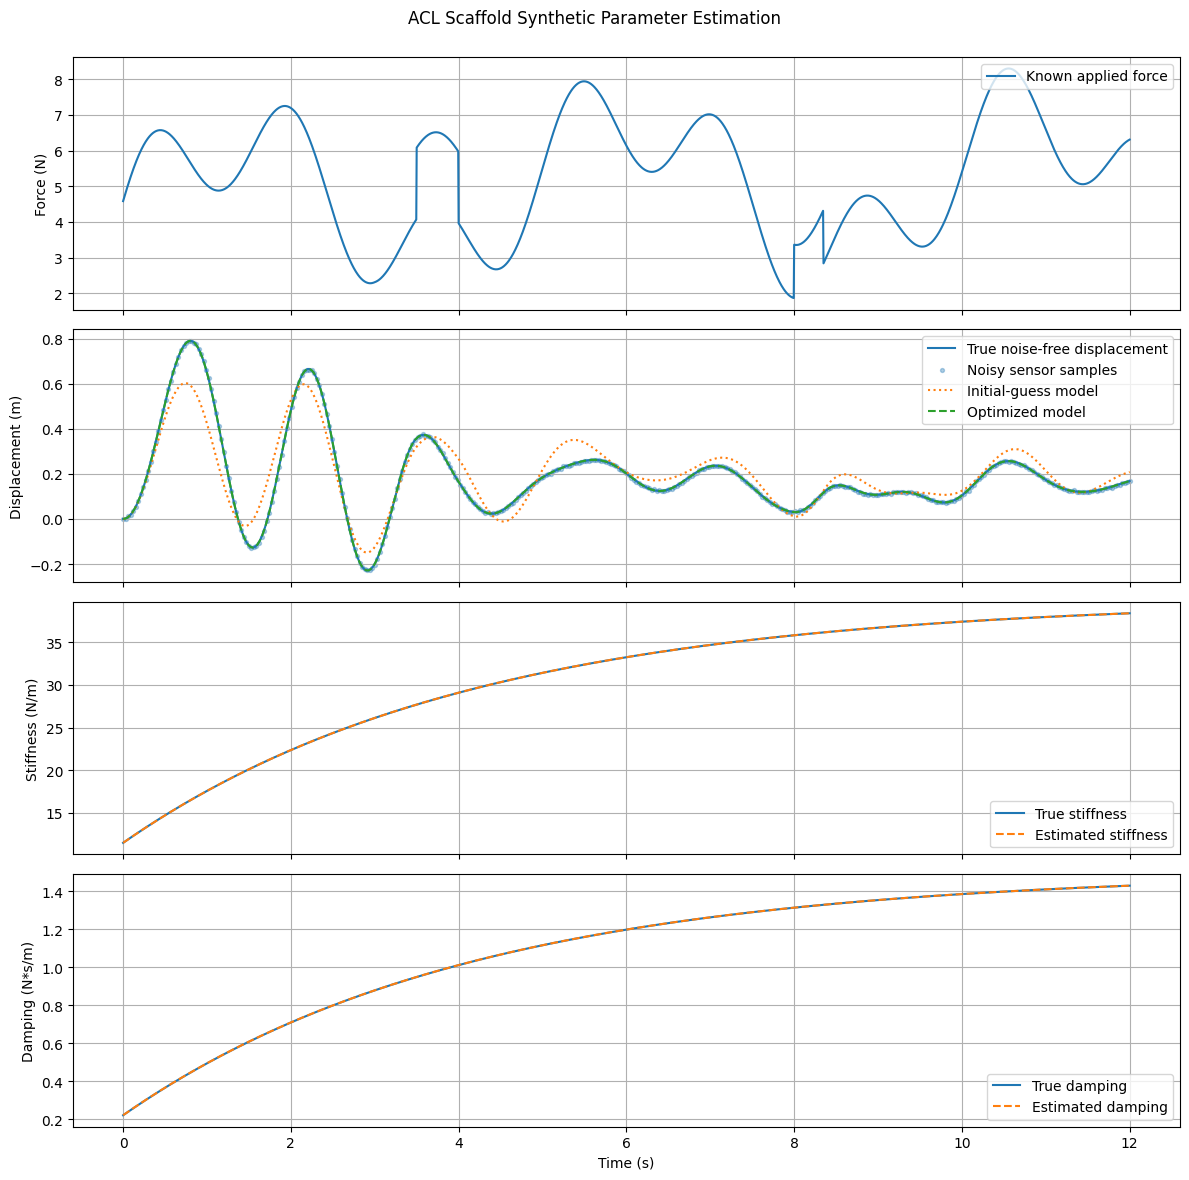

Figure saved as acl_master_parameter_estimation_results.png


In [ ]:
figure, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
figure.suptitle("ACL Scaffold Synthetic Parameter Estimation")

axes[0].plot(time, force, label="Known applied force")
axes[0].set_ylabel("Force (N)")
axes[0].grid(True)
axes[0].legend(loc="upper right")

sample_spacing = max(1, len(time) // 400)
axes[1].plot(time, true_model["displacement"], label="True noise-free displacement")
axes[1].scatter(
    time[::sample_spacing],
    sensor_displacement[::sample_spacing],
    s=8,
    alpha=0.35,
    label="Noisy sensor samples",
)
axes[1].plot(
    time,
    initial_model["displacement"],
    linestyle=":",
    label="Initial-guess model",
)
axes[1].plot(
    time,
    estimated_model["displacement"],
    linestyle="--",
    label="Optimized model",
)
axes[1].set_ylabel("Displacement (m)")
axes[1].grid(True)
axes[1].legend(loc="upper right")

axes[2].plot(time, true_model["stiffness"], label="True stiffness")
axes[2].plot(
    time,
    estimated_model["stiffness"],
    linestyle="--",
    label="Estimated stiffness",
)
axes[2].set_ylabel("Stiffness (N/m)")
axes[2].grid(True)
axes[2].legend(loc="lower right")

axes[3].plot(time, true_model["damping"], label="True damping")
axes[3].plot(
    time,
    estimated_model["damping"],
    linestyle="--",
    label="Estimated damping",
)
axes[3].set_xlabel("Time (s)")
axes[3].set_ylabel("Damping (N*s/m)")
axes[3].grid(True)
axes[3].legend(loc="lower right")

figure.tight_layout(rect=(0.0, 0.0, 1.0, 0.98))
figure.savefig(
    "acl_master_parameter_estimation_results.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

print("Figure saved as acl_master_parameter_estimation_results.png")

## 11. Interpretation and limitations

The close recovery shows that the inverse-estimation code is internally consistent: when the assumed equations are correct and the force input is informative, nonlinear least squares can recover \(k_{\min}\), \(c_{\min}\), and \(\alpha\) from noisy displacement data.

This is still an intentionally favorable test because the same mathematical model generates and fits the data. Real hardware may introduce fixture compliance, friction, actuator backlash, sensor offsets, timing mismatch, nonlinear material behavior, hysteresis, and uncertainty in the effective mass. Therefore, this notebook verifies the **algorithmic workflow**, not yet the physical accuracy of the digital twin.

## 12. Replacing synthetic measurements with benchtop data

The future hardware CSV should contain exactly:

- `time_s`
- `force_N`
- `displacement_m`

The loading function below checks the columns and returns NumPy arrays that can replace `time`, `force`, and `sensor_displacement` in the optimizer call.

In [ ]:
def load_hardware_csv(csv_path):
    """Load time, force, and displacement arrays from a benchtop CSV file."""
    hardware_data = pd.read_csv(csv_path)
    required_columns = ["time_s", "force_N", "displacement_m"]

    if list(hardware_data.columns) != required_columns:
        raise ValueError(
            "CSV columns must be exactly: time_s, force_N, displacement_m"
        )
    if len(hardware_data) < 2:
        raise ValueError("CSV must contain at least two data rows")
    if hardware_data.isnull().any().any():
        raise ValueError("CSV cannot contain missing values")

    hardware_time = hardware_data["time_s"].to_numpy(dtype=float)
    hardware_force = hardware_data["force_N"].to_numpy(dtype=float)
    hardware_displacement = hardware_data["displacement_m"].to_numpy(dtype=float)

    return hardware_time, hardware_force, hardware_displacement


# Future use:
# time, force, sensor_displacement = load_hardware_csv("real_scaffold_trial.csv")
# Then rerun the least_squares cell using the measured arrays.

## 13. Optional multi-profile benchtop experiments

This section simulates four separate benchtop trials. In each trial:

1. A hidden scaffold model is driven by a **true force profile**.
2. Load-cell noise is added to create measured force:

\[
F_{\mathrm{measured}}(t)=F_{\mathrm{true}}(t)+\eta_F(t)
\]

3. Displacement-sensor or strain-derived displacement noise is added:

\[
x_{\mathrm{measured}}(t)=x_{\mathrm{true}}(t)+\eta_x(t)
\]

4. The optimizer receives only the noisy measured force and noisy measured displacement.

This is more representative of the planned test rig than the main proof of concept, but it remains synthetic. The four loading profiles are a constant hold, cyclic rehabilitation loading, a gradual ramp, and sudden pulses. Their different parameter-recovery errors help indicate which physical experiment is most informative.

In [ ]:
def create_experimental_force_profiles(time):
    """Return four nonnegative force profiles representing separate benchtop trials."""
    time = np.asarray(time, dtype=float)
    if time.ndim != 1 or len(time) < 2:
        raise ValueError("time must contain at least two samples")

    constant_hold = np.full_like(time, 5.0)
    cyclic_rehab = 5.0 + 3.0 * np.sin(2.0 * np.pi * 0.45 * time)
    gradual_ramp = 8.0 * np.clip(time / 4.0, 0.0, 1.0)

    sudden_pulses = np.full_like(time, 1.0)
    sudden_pulses += 7.0 * ((time >= 2.0) & (time < 2.6))
    sudden_pulses += 5.0 * ((time >= 6.0) & (time < 6.4))
    sudden_pulses += 6.0 * ((time >= 9.0) & (time < 9.25))

    return {
        "Constant hold": np.maximum(constant_hold, 0.0),
        "Cyclic rehabilitation": np.maximum(cyclic_rehab, 0.0),
        "Gradual ramp": np.maximum(gradual_ramp, 0.0),
        "Sudden pulses": np.maximum(sudden_pulses, 0.0),
    }


def add_benchtop_sensor_noise(
    true_force,
    true_displacement,
    force_noise_std,
    displacement_noise_std,
    random_seed,
):
    """Add independent Gaussian noise to load-cell and displacement measurements."""
    true_force = np.asarray(true_force, dtype=float)
    true_displacement = np.asarray(true_displacement, dtype=float)

    if true_force.shape != true_displacement.shape:
        raise ValueError("force and displacement must have matching shapes")
    if force_noise_std <= 0 or displacement_noise_std <= 0:
        raise ValueError("both sensor-noise standard deviations must be positive")

    generator = np.random.default_rng(random_seed)
    measured_force = true_force + generator.normal(
        0.0,
        force_noise_std,
        size=true_force.shape,
    )
    measured_displacement = true_displacement + generator.normal(
        0.0,
        displacement_noise_std,
        size=true_displacement.shape,
    )

    return measured_force, measured_displacement


def estimate_experimental_trial(
    time,
    measured_force,
    measured_displacement,
    displacement_noise_std,
):
    """Estimate k_min, c_min, and alpha from one noisy benchtop-style trial."""
    result = least_squares(
        parameter_residuals,
        x0=initial_guess,
        bounds=(lower_bounds, upper_bounds),
        args=(
            time,
            measured_force,
            measured_displacement,
            displacement_noise_std,
            mass,
            k_max,
            c_max,
            q0,
            x0,
            v0,
        ),
        method="trf",
        loss="linear",
        x_scale="jac",
        max_nfev=300,
    )

    fitted_model = run_forward_model(
        time=time,
        force=measured_force,
        k_min=result.x[0],
        c_min=result.x[1],
        alpha=result.x[2],
        mass=mass,
        k_max=k_max,
        c_max=c_max,
        q0=q0,
        x0=x0,
        v0=v0,
    )

    return result, fitted_model

In [ ]:
# Noise levels used for this benchtop-style robustness study.
force_noise_std = 0.05                       # N, synthetic load-cell noise
experimental_displacement_noise_std = 0.002 # m, synthetic displacement noise

experimental_force_profiles = create_experimental_force_profiles(time)
experimental_trial_results = {}
experimental_rows = []

for trial_index, (profile_name, true_force_profile) in enumerate(
    experimental_force_profiles.items(),
    start=1,
):
    # The hidden physical system responds to the true force, not the noisy reading.
    trial_true_model = run_forward_model(
        time=time,
        force=true_force_profile,
        k_min=true_k_min,
        c_min=true_c_min,
        alpha=true_alpha,
        mass=mass,
        k_max=k_max,
        c_max=c_max,
        q0=q0,
        x0=x0,
        v0=v0,
    )

    measured_force, measured_displacement = add_benchtop_sensor_noise(
        true_force=true_force_profile,
        true_displacement=trial_true_model["displacement"],
        force_noise_std=force_noise_std,
        displacement_noise_std=experimental_displacement_noise_std,
        random_seed=1000 + trial_index,
    )

    trial_optimizer, trial_fitted_model = estimate_experimental_trial(
        time=time,
        measured_force=measured_force,
        measured_displacement=measured_displacement,
        displacement_noise_std=experimental_displacement_noise_std,
    )

    estimated_parameters = trial_optimizer.x
    relative_errors = np.abs((estimated_parameters - true_values) / true_values)
    fitted_rmse = np.sqrt(np.mean(
        (trial_fitted_model["displacement"] - measured_displacement) ** 2
    ))

    safe_file_name = profile_name.lower().replace(" ", "_")
    trial_data = pd.DataFrame({
        "time_s": time,
        "true_force_N": true_force_profile,
        "measured_force_N": measured_force,
        "true_displacement_m": trial_true_model["displacement"],
        "measured_displacement_m": measured_displacement,
    })
    trial_data.to_csv(
        f"acl_benchtop_{safe_file_name}.csv",
        index=False,
    )

    experimental_trial_results[profile_name] = {
        "true_force": true_force_profile,
        "measured_force": measured_force,
        "measured_displacement": measured_displacement,
        "true_model": trial_true_model,
        "fitted_model": trial_fitted_model,
        "optimizer": trial_optimizer,
    }

    experimental_rows.append({
        "Force profile": profile_name,
        "Estimated k_min": estimated_parameters[0],
        "Estimated c_min": estimated_parameters[1],
        "Estimated alpha": estimated_parameters[2],
        "k_min error (%)": 100.0 * relative_errors[0],
        "c_min error (%)": 100.0 * relative_errors[1],
        "alpha error (%)": 100.0 * relative_errors[2],
        "Fit RMSE (m)": fitted_rmse,
        "Optimizer succeeded": bool(trial_optimizer.success),
    })

experimental_results_table = pd.DataFrame(experimental_rows)
experimental_results_table

,Force profile,Estimated k_min,Estimated c_min,Estimated alpha,k_min error (%),c_min error (%),alpha error (%),Fit RMSE (m),Optimizer succeeded
0,Constant hold,11.486021,0.223362,0.240871,0.121560,1.528243,0.363002,0.002087,True
1,Cyclic rehabilitation,11.505433,0.216182,0.239704,0.047241,1.735255,0.123448,0.001990,True
2,Gradual ramp,11.602231,0.181362,0.239137,0.888966,17.562602,0.359493,0.002032,True
3,Sudden pulses,11.381452,0.211061,0.241194,1.030855,4.063077,0.497576,0.002049,True


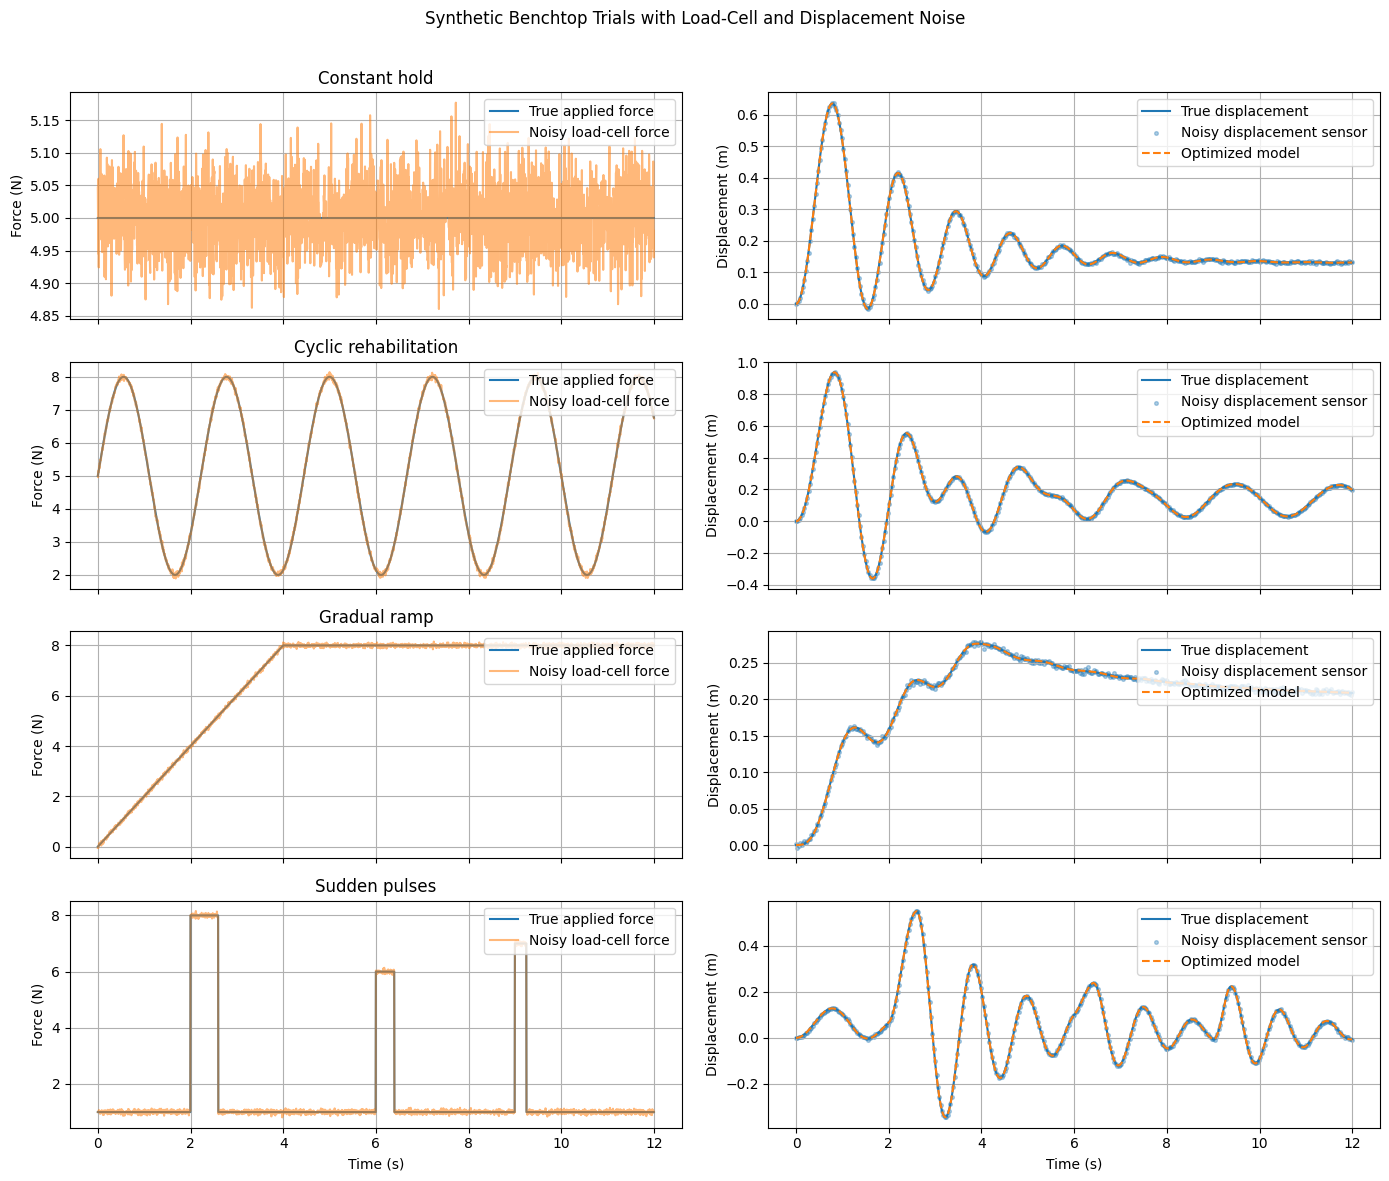

Saved one CSV per force profile and acl_multi_profile_benchtop_trials.png


In [ ]:
figure, axes = plt.subplots(
    len(experimental_trial_results),
    2,
    figsize=(14, 12),
    sharex=True,
)
figure.suptitle("Synthetic Benchtop Trials with Load-Cell and Displacement Noise")

for row_index, (profile_name, trial) in enumerate(experimental_trial_results.items()):
    force_axis = axes[row_index, 0]
    displacement_axis = axes[row_index, 1]

    force_axis.plot(time, trial["true_force"], label="True applied force")
    force_axis.plot(
        time,
        trial["measured_force"],
        alpha=0.55,
        label="Noisy load-cell force",
    )
    force_axis.set_ylabel("Force (N)")
    force_axis.set_title(profile_name)
    force_axis.grid(True)
    force_axis.legend(loc="upper right")

    displacement_axis.plot(
        time,
        trial["true_model"]["displacement"],
        label="True displacement",
    )
    displacement_axis.scatter(
        time[::sample_spacing],
        trial["measured_displacement"][::sample_spacing],
        s=7,
        alpha=0.35,
        label="Noisy displacement sensor",
    )
    displacement_axis.plot(
        time,
        trial["fitted_model"]["displacement"],
        linestyle="--",
        label="Optimized model",
    )
    displacement_axis.set_ylabel("Displacement (m)")
    displacement_axis.grid(True)
    displacement_axis.legend(loc="upper right")

axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")
figure.tight_layout(rect=(0.0, 0.0, 1.0, 0.97))
figure.savefig(
    "acl_multi_profile_benchtop_trials.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

print("Saved one CSV per force profile and acl_multi_profile_benchtop_trials.png")

## 14. Optional validation checks

These compact checks test three known behaviors:

1. Zero force and zero initial motion remain at zero.
2. A damped constant-parameter system approaches the static equilibrium `force / stiffness`.
3. Low-noise synthetic data allow recovery of all three hidden parameters within a small tolerance.

In [ ]:
# Check 1: zero input and zero initial conditions must remain at zero.
validation_time = create_time_array(2.0, 0.001)
zero_force = np.zeros_like(validation_time)
constant_stiffness = np.full_like(validation_time, 25.0)
constant_damping = np.full_like(validation_time, 0.6)

zero_response = simulate_displacement(
    validation_time,
    zero_force,
    mass=1.0,
    stiffness=constant_stiffness,
    damping=constant_damping,
    x0=0.0,
    v0=0.0,
)
zero_input_check = np.max(np.abs(zero_response)) < 1e-12

# Check 2: constant force should approach the static equilibrium F/k.
equilibrium_time = create_time_array(20.0, 0.001)
equilibrium_force = np.full_like(equilibrium_time, 5.0)
equilibrium_stiffness = np.full_like(equilibrium_time, 20.0)
equilibrium_damping = np.full_like(equilibrium_time, 4.0)

equilibrium_response = simulate_displacement(
    equilibrium_time,
    equilibrium_force,
    mass=1.0,
    stiffness=equilibrium_stiffness,
    damping=equilibrium_damping,
)
expected_equilibrium = 5.0 / 20.0
equilibrium_check = abs(equilibrium_response[-1] - expected_equilibrium) < 0.002

# Check 3: repeat estimation with much lower sensor noise.
low_noise_std = 0.0002
low_noise_generator = np.random.default_rng(456)
low_noise_measurements = (
    true_model["displacement"]
    + low_noise_generator.normal(0.0, low_noise_std, size=time.shape)
)

low_noise_result = least_squares(
    parameter_residuals,
    x0=initial_guess,
    bounds=(lower_bounds, upper_bounds),
    args=(
        time,
        force,
        low_noise_measurements,
        low_noise_std,
        mass,
        k_max,
        c_max,
        q0,
        x0,
        v0,
    ),
    method="trf",
    x_scale="jac",
    max_nfev=300,
)

low_noise_relative_errors = np.abs(
    (low_noise_result.x - true_values) / true_values
)
parameter_recovery_check = (
    low_noise_result.success
    and np.all(low_noise_relative_errors < 0.01)
)

validation_results = pd.DataFrame({
    "Validation check": [
        "Zero-input response",
        "Constant-force equilibrium",
        "Low-noise parameter recovery",
    ],
    "Passed": [
        zero_input_check,
        equilibrium_check,
        parameter_recovery_check,
    ],
})

all_validation_checks_passed = bool(validation_results["Passed"].all())

print(validation_results.to_string(index=False))
print("\nAll optional validation checks passed:", all_validation_checks_passed)

assert all_validation_checks_passed

            Validation check  Passed
         Zero-input response    True
  Constant-force equilibrium    True
Low-noise parameter recovery    True

All optional validation checks passed: True
